In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isna().sum())

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['customerID'])
df.shape

Missing TotalCharges after conversion: 11


(7043, 20)

In [7]:
# Separate target
y_raw = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop(columns=['Churn'])

# One-hot encode categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Features before encoding:", X.shape[1])
print("Features after encoding:", X_encoded.shape[1])
X_encoded.head()

Features before encoding: 19
Features after encoding: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [8]:
# One-hot encode the target for Softmax output
y_onehot = to_categorical(y_raw, num_classes=2)
y_onehot[:5]

array([[1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_onehot, test_size=0.2, random_state=42, stratify=y_raw
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


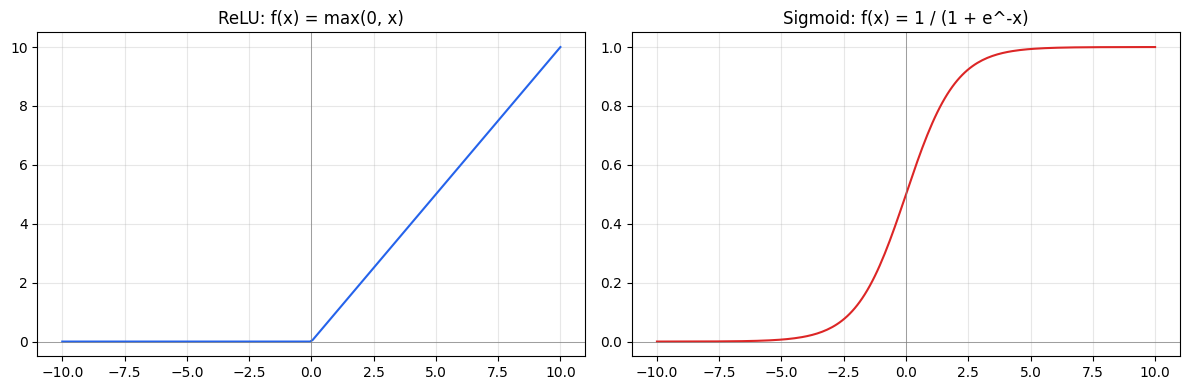

In [10]:
x = np.linspace(-10, 10, 200)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, relu, color='#2563eb')
axes[0].set_title('ReLU: f(x) = max(0, x)')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].grid(alpha=0.3)

axes[1].plot(x, sigmoid, color='#dc2626')
axes[1].set_title('Sigmoid: f(x) = 1 / (1 + e^-x)')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/activation_functions.png', dpi=120)
plt.show()

In [11]:
raw_scores = np.array([2.0, 1.0, 0.1])
softmax_probs = np.exp(raw_scores) / np.sum(np.exp(raw_scores))
print("Raw scores:", raw_scores)
print("Softmax probabilities:", softmax_probs)
print("Sum:", softmax_probs.sum())

Raw scores: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0


In [12]:
num_features = X_train_scaled.shape[1]
num_classes = 2

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(num_features,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\COMPUTER ARENA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,130 (16.13 KB)

 Trainable params: 4,130 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7533 - loss: 0.4909 - val_accuracy: 0.7826 - val_loss: 0.4579
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8001 - loss: 0.4212 - val_accuracy: 0.7879 - val_loss: 0.4508
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8056 - loss: 0.4105 - val_accuracy: 0.7915 - val_loss: 0.4496
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8101 - loss: 0.4039 - val_accuracy: 0.7897 - val_loss: 0.4492
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8138 - loss: 0.3990 - val_accuracy: 0.7870 - val_loss: 0.4500
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8187 - loss: 0.3947 - val_accuracy: 0.7853 - val_loss: 0.4507
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8221 - loss: 0.3908 - val_accuracy: 0.7808 - val_loss: 0.4519
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8256 - loss: 0.3873 - val_accuracy: 0.

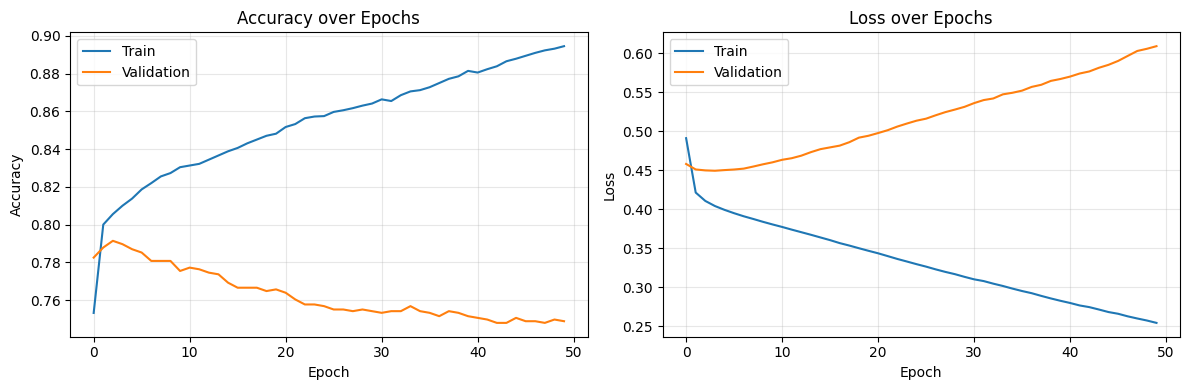

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/basic_ann_curves.png', dpi=120)
plt.show()

In [16]:
def build_model(hidden_layers, num_features=num_features, num_classes=num_classes):
    layers = [keras.layers.Dense(hidden_layers[0], activation='relu', input_shape=(num_features,))]
    for units in hidden_layers[1:]:
        layers.append(keras.layers.Dense(units, activation='relu'))
    layers.append(keras.layers.Dense(num_classes, activation='softmax'))
    m = keras.Sequential(layers)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

architectures = {
    'small':  [16, 8],
    'medium': [64, 32],
    'large':  [256, 128, 64],
}

histories = {}
for name, layers_config in architectures.items():
    print(f"Training '{name}' architecture: {layers_config}")
    m = build_model(layers_config)
    h = m.fit(
        X_train_scaled, y_train,
        epochs=50, batch_size=32,
        validation_split=0.2, verbose=0
    )
    histories[name] = h
    print(f"  Final val_accuracy: {h.history['val_accuracy'][-1]:.4f}")

Training 'small' architecture: [16, 8]
  Final val_accuracy: 0.7817
Training 'medium' architecture: [64, 32]
  Final val_accuracy: 0.7418
Training 'large' architecture: [256, 128, 64]
  Final val_accuracy: 0.7604


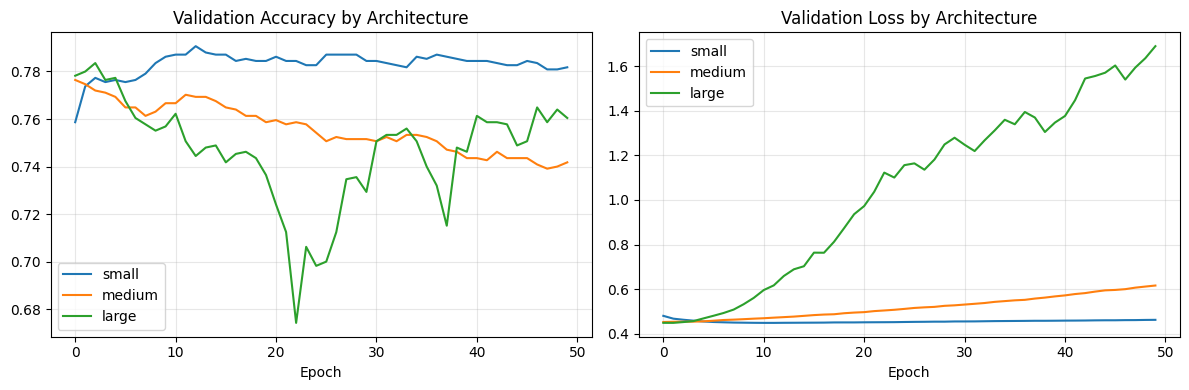

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'], label=name)

axes[0].set_title('Validation Accuracy by Architecture')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss by Architecture')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/architecture_comparison.png', dpi=120)
plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"ANN Test Accuracy: {test_accuracy:.4f}")
print(f"ANN Test Loss: {test_loss:.4f}")

ANN Test Accuracy: 0.7509
ANN Test Loss: 0.6394


In [19]:
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_labels)
log_reg_acc = accuracy_score(y_test_labels, log_reg.predict(X_test_scaled))

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train_labels)
rf_acc = accuracy_score(y_test_labels, rf.predict(X_test_scaled))

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Simple ANN'],
    'Test Accuracy': [log_reg_acc, rf_acc, test_accuracy]
}).sort_values('Test Accuracy', ascending=False)

comparison

,Model,Test Accuracy
0,Logistic Regression,0.806955
1,Random Forest,0.789922
2,Simple ANN,0.750887


Reflection: Forward Propagation & Backpropagation

**Forward Propagation:**

Jab hum kisi bhi data point (jaise ek customer ka age, income, tenure, etc.) model ko dete hain, to woh input layer se enter hota hai. Har neuron us input ko apne weight se multiply karta hai, sab ko add karta hai (plus ek bias), aur phir activation function (jaise ReLU) se pass karta hai. Yeh process layer by layer aage badhta hai — pehli hidden layer ka output dusri hidden layer ka input banta hai — jab tak hum output layer tak nahi pahunchte, jahan Softmax final prediction (probability) deta hai. Isko "forward" isliye kehte hain kyunki data sirf ek direction mein — input se output ki taraf — flow karta hai. Yeh bilkul waise hai jaise ek factory assembly line: raw material (input) har station (layer) se guzarta hai aur har station usme kuch add/process karta hai, jab tak final product (prediction) tayar nahi ho jata.

**Backpropagation:**

Forward propagation ke baad model ek prediction deta hai, lekin shuru mein yeh prediction galat hoti hai kyunki weights random hote hain. Hum is prediction ko actual label (jaise customer ne sach mein churn kiya ya nahi) se compare karte hain, aur ek loss function (jaise categorical cross-entropy) se calculate karte hain ke prediction kitni "galat" thi. Backpropagation phir is error ko network mein **peeche ki taraf** (output se input tak) waapas bhejta hai, aur calculus (chain rule) use karke yeh nikalta hai ke har individual weight ne is error mein kitna contribute kiya. Gradient Descent phir har weight ko thoda sa adjust karta hai — us direction mein jo error ko kam kare — learning rate ke hisaab se. Yeh pura process (forward → loss calculate → backward → weight update) hazaron baar repeat hota hai, jab tak model ki predictions accurate na ho jayein.

**Simple analogy:** socho tum darts khel rahe ho aankhein band karke. Pehla throw (forward pass) galat jagah lagta hai. Koi tumhe batata hai ke tum kitna aur kis direction mein miss huye (loss). Agli baar tum apna angle thoda adjust karte ho us feedback ke basis par (backpropagation + weight update). Baar baar throw karne se (epochs) tumhara aim better hota jata hai.